In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv('diabetes.csv')

In [ ]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
dataset.shape

(768, 9)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
dataset.duplicated().sum()

np.int64(0)

/tmp/ipykernel_703/2281641348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Outcome', data=dataset, palette=['#4C72B0', '#C44E52'])


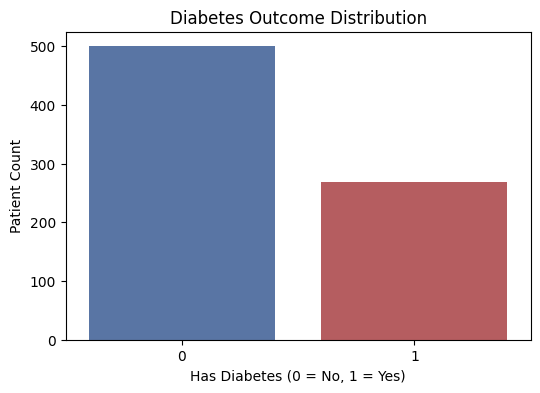

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=dataset, palette=['#4C72B0', '#C44E52'])
plt.title('Diabetes Outcome Distribution', fontsize=12)
plt.xlabel('Has Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
plt.show()

<Axes: xlabel='BMI', ylabel='Count'>

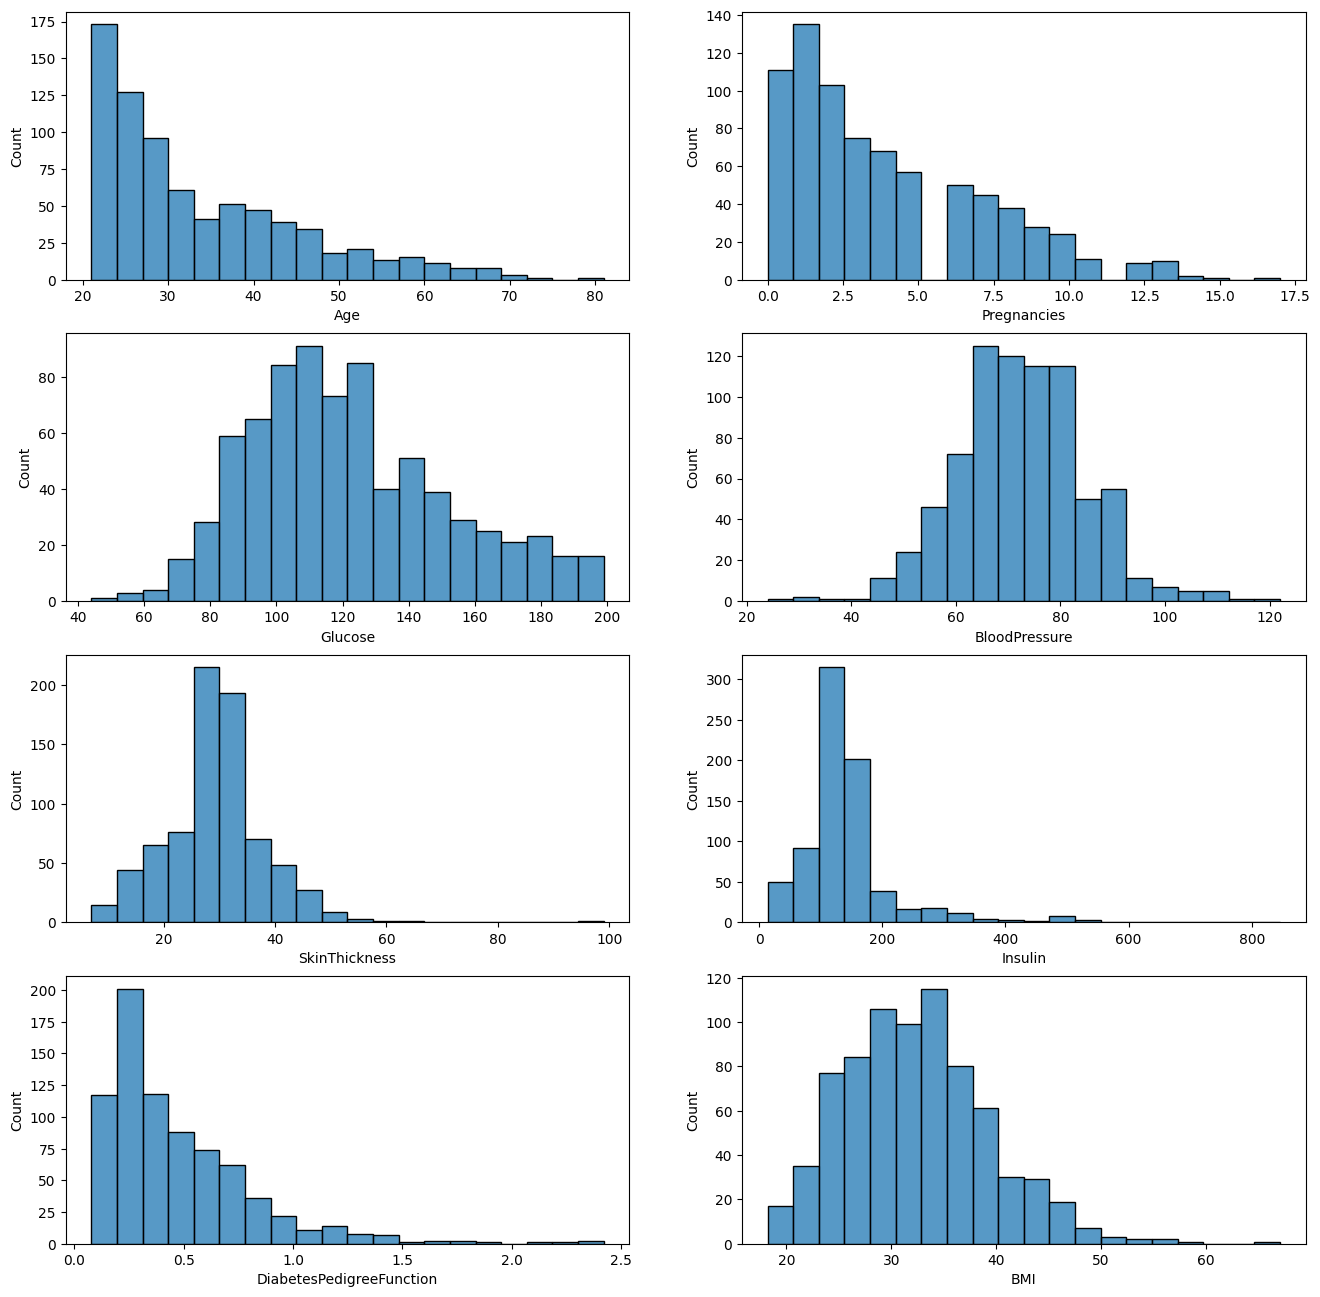

In [ ]:
fig, ax = plt.subplots(4,2, figsize=(16,16))
sns.histplot(dataset.Age, bins = 20, ax=ax[0,0])
sns.histplot(dataset.Pregnancies, bins = 20, ax=ax[0,1])
sns.histplot(dataset.Glucose, bins = 20, ax=ax[1,0])
sns.histplot(dataset.BloodPressure, bins = 20, ax=ax[1,1])
sns.histplot(dataset.SkinThickness, bins = 20, ax=ax[2,0])
sns.histplot(dataset.Insulin, bins = 20, ax=ax[2,1])
sns.histplot(dataset.DiabetesPedigreeFunction, bins = 20, ax=ax[3,0])
sns.histplot(dataset.BMI, bins = 20, ax=ax[3,1])

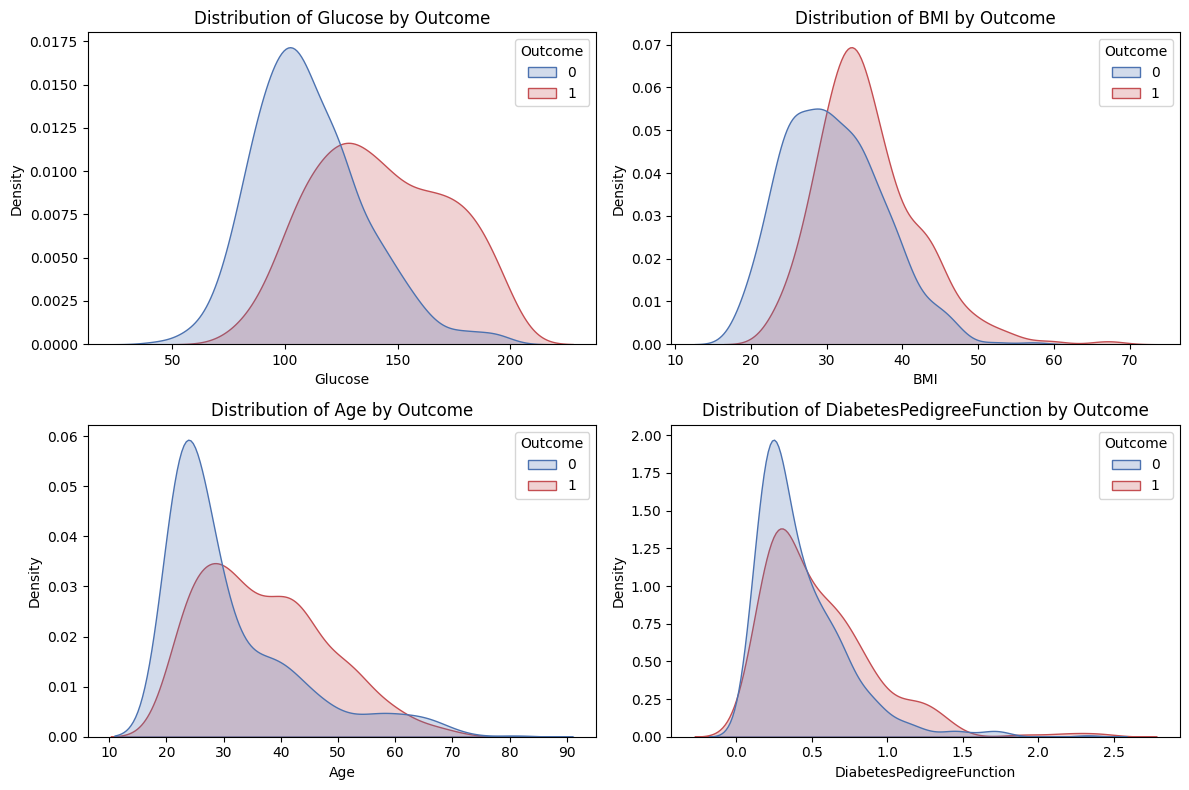

In [ ]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.kdeplot(data=dataset, x=col, hue='Outcome', common_norm=False, fill=True, ax=axes[i], palette=['#4C72B0', '#C44E52'])
    axes[i].set_title(f'Distribution of {col} by Outcome')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

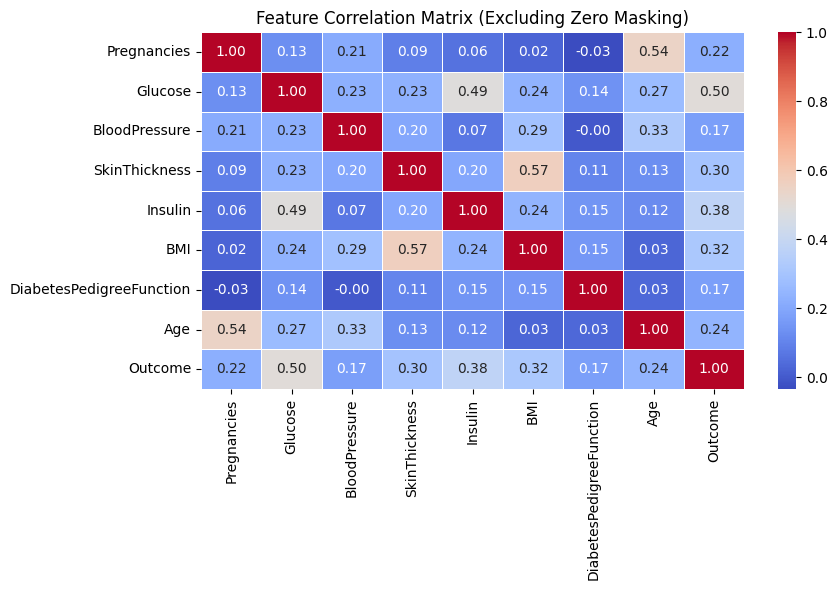

In [ ]:
plt.figure(figsize=(9, 6))
# Exclude zero values during correlation calculation for accuracy
corr_matrix = dataset.replace({col: {0: np.nan} for col in zero_cols}).corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix (Excluding Zero Masking)')
plt.tight_layout()
plt.show()

In [ ]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
dataset[zero_cols] = dataset[zero_cols].replace(0, np.nan)

In [ ]:
X = dataset.drop(columns='Outcome')
y = dataset['Outcome']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('median_imputer', SimpleImputer(strategy='median'), ['SkinThickness', 'Insulin', 'BMI']),
        ('mean_imputer', SimpleImputer(strategy='mean'), ['Glucose', 'BloodPressure'])
    ],
    remainder='passthrough'  # Keeps Pregnancies, DiabetesPedigreeFunction, Age
)
feature_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler())
])

In [ ]:
X_train_scaled = feature_pipeline.fit_transform(X_train)
X_test_scaled = feature_pipeline.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [ ]:
comparison = pd.DataFrame(results).set_index("Model").round(3)
print(comparison)

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.708      0.588   0.556     0.571    0.826
Decision Tree           0.825      0.755   0.741     0.748    0.912
Random Forest           0.864      0.824   0.778     0.800    0.947


In [ ]:
rf_model = models["Random Forest"]
rf_pred = rf_model.predict(X_test_scaled)

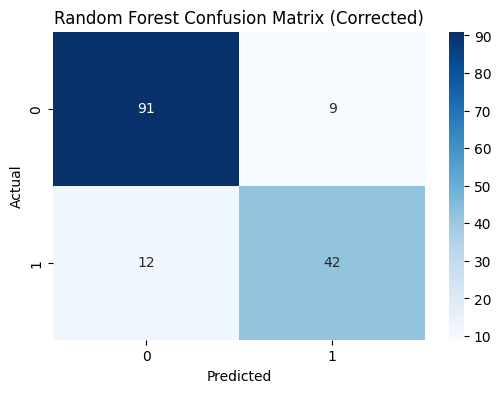

In [ ]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix (Corrected)')
plt.show()

In [ ]:
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred))


Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       100
           1       0.82      0.78      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.84      0.85       154
weighted avg       0.86      0.86      0.86       154

